# 01 — Análise descritiva do MovieLens 100k
**Laboratório de Estatística Aplicada — 2026/2 | Professor Victor Coscrato**  
**Isabella Viana Bambirra**

O problema é encontrar filmes relevantes para cada usuário a partir de avaliações explícitas: as pessoas informam notas de 1 a 5. A filtragem colaborativa procura padrões nesse histórico, compartilhados por usuários e filmes. Uma nota ausente é desconhecida; não é zero, rejeição ou ausência de interesse.

Seguimos as páginas 12 e 33–36 do material da disciplina. Este notebook conhece a base inteira para descrição. Na avaliação, as estatísticas e os modelos serão calculados novamente dentro de cada treino. Idade, gênero, ocupação e gêneros dos filmes não serão covariáveis dos modelos.

Antes de olhar os vencedores, fixamos **50 avaliações** como mínimo para o ranking de médias: é uma proteção descritiva simples contra médias extremas de filmes com poucas notas, e não elimina a incerteza nem constitui teste estatístico.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
from projeto import *
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False, 'axes.spines.right': False})
ratings, users, items = load_data()
display(versions())

{'python': '3.12.14',
 'numpy': '1.26.4',
 'pandas': '3.0.6',
 'matplotlib': '3.11.2',
 'scikit-learn': '1.9.1',
 'scikit-surprise': '1.1.5',
 'nbformat': '5.11.1',
 'nbclient': '0.11.0',
 'ipykernel': '7.4.0'}

## 1. Fonte, leitura e integridade
A base foi obtida de [GroupLens](https://grouplens.org/datasets/movielens/100k/). O README original acompanha o download em `data/raw/ml-100k/README`. A amostra já foi filtrada na origem para usuários com pelo menos 20 avaliações e demografia completa.

`u.data` usa tabulação; `u.user` e `u.item` usam `|`. Apesar da descrição genérica de tabulação no README, os arquivos de metadados efetivamente usam barras verticais. Os filmes são lidos em **Latin-1**; datas de lançamento em dia–mês abreviado–ano. O timestamp é Unix em segundos, interpretado em UTC. CEPs são texto. As funções conferem tamanhos, IDs, notas, pares únicos e junções muitos-para-um. Não removemos registros nem imputamos metadados.

In [2]:
display(ratings.head())
display(ratings.dtypes.to_frame('tipo'))
display(users.dtypes.to_frame('tipo'))
display(items.dtypes.to_frame('tipo'))
audit = pd.DataFrame({'arquivo': ['avaliações','usuários','filmes'], 'linhas': [len(ratings),len(users),len(items)], 'IDs distintos': [ratings.user_id.nunique(),users.user_id.nunique(),items.item_id.nunique()]})
display(save(audit,'integrity'))
missing = pd.concat([users.isna().sum().rename('users'),items.isna().sum().rename('items')],axis=1).fillna(0)
display(save(missing.reset_index(names='variavel'),'metadata_missing'))
dates = pd.to_datetime(ratings.timestamp, unit='s', utc=True)
print('Período UTC:', dates.min(), 'até', dates.max())
print('Duplicidades usuário–filme:', ratings.duplicated(['user_id','item_id']).sum())

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


,tipo
user_id,int64
item_id,int64
rating,int64
timestamp,int64


,tipo
user_id,int64
age,int64
gender,str
occupation,str
zip_code,str


,tipo
item_id,int64
title,str
release_date,str
video_release_date,float64
imdb_url,str
unknown,int64
Action,int64
Adventure,int64
Animation,int64
Children's,int64


,arquivo,linhas,IDs distintos
0,avaliações,100000,943
1,usuários,943,943
2,filmes,1682,1682


,variavel,users,items
0,user_id,0.0,0.0
1,age,0.0,0.0
2,gender,0.0,0.0
3,occupation,0.0,0.0
4,zip_code,0.0,0.0
5,item_id,0.0,0.0
6,title,0.0,0.0
7,release_date,0.0,1.0
8,video_release_date,0.0,1682.0
9,imdb_url,0.0,3.0


Período UTC: 1997-09-20 03:05:10+00:00 até 1998-04-22 23:10:38+00:00
Duplicidades usuário–filme: 0


In [3]:
display(Markdown(f"A conferência encontrou **{len(ratings):,} notas, {len(users)} usuários e {len(items)} filmes**, sem pares usuário–filme repetidos. Há {items.release_date.isna().sum()} datas de lançamento ausentes e {items.imdb_url.isna().sum()} URLs ausentes. A data de lançamento em vídeo está ausente para {items.video_release_date.isna().sum()} filmes; não é usada. Esses casos permanecem na base. A coleta vai de {dates.min().date()} a {dates.max().date()}, portanto retrata um catálogo e um público históricos."))

A conferência encontrou **100,000 notas, 943 usuários e 1682 filmes**, sem pares usuário–filme repetidos. Há 1 datas de lançamento ausentes e 3 URLs ausentes. A data de lançamento em vídeo está ausente para 1682 filmes; não é usada. Esses casos permanecem na base. A coleta vai de 1997-09-20 a 1998-04-22, portanto retrata um catálogo e um público históricos.

## 2. Da tabela à matriz de avaliações
Cada linha da matriz é um usuário e cada coluna é um filme, como na página 12. A tabela longa guarda somente células observadas; `pivot` preserva as demais como `NaN`. O recorte abaixo usa os cinco primeiros usuários e os oito primeiros filmes por ID, sem seleção de padrões visualmente favoráveis.

In [4]:
matrix_excerpt = ratings.pivot(index='user_id',columns='item_id',values='rating').reindex(index=range(1,6),columns=range(1,9))
display(matrix_excerpt)

item_id,1,2,3,4,5,6,7,8
user_id,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN


Cada `NaN` exige uma estimativa se o filme for candidato à recomendação. Prever essa nota e escolher dez filmes são tarefas relacionadas, mas não idênticas: um modelo pode aproximar bem as notas observadas e ainda ordenar mal os candidatos.

## 3. Distribuição das notas
Calculamos contagens, proporções e medidas de posição e dispersão para reconhecer a escala e a concentração do feedback. Isso também orienta a interpretação de erros futuros: RMSE será medido em estrelas.

,nota,frequencia,proporcao
0,1,6110,0.06110
1,2,11370,0.11370
2,3,27145,0.27145
3,4,34174,0.34174
4,5,21201,0.21201


,estatistica,valor
0,count,100000.000000
1,mean,3.529860
2,std,1.125674
3,min,1.000000
4,5%,1.000000
5,25%,3.000000
6,50%,4.000000
7,75%,4.000000
8,95%,5.000000
9,max,5.000000


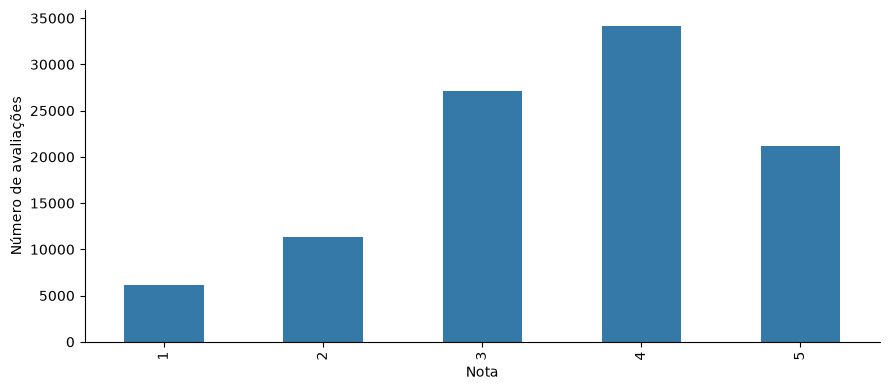

In [5]:
frequency = ratings.rating.value_counts().sort_index().rename('frequencia').to_frame()
frequency['proporcao'] = frequency.frequencia / len(ratings)
display(save(frequency.reset_index(names='nota'),'rating_distribution'))
display(save(ratings.rating.describe(percentiles=[.05,.25,.5,.75,.95]).to_frame('valor').reset_index(names='estatistica'),'rating_summary'))
frequency.frequencia.plot.bar(color='#3579a8'); plt.xlabel('Nota'); plt.ylabel('Número de avaliações')
plt.tight_layout(); plt.savefig(FIGURES / 'rating_distribution.png', dpi=150); plt.show()

In [6]:
display(Markdown(f"A média é **{ratings.rating.mean():.3f}**, a mediana é **{ratings.rating.median():.0f}** e o desvio-padrão é **{ratings.rating.std():.3f}**. Notas 4 e 5 representam **{ratings.rating.ge(4).mean():.1%}** das avaliações. A concentração nas notas altas descreve filmes escolhidos e avaliados por esse público; não demonstra que filmes desconhecidos receberiam o mesmo padrão de notas."))

A média é **3.530**, a mediana é **4** e o desvio-padrão é **1.126**. Notas 4 e 5 representam **55.4%** das avaliações. A concentração nas notas altas descreve filmes escolhidos e avaliados por esse público; não demonstra que filmes desconhecidos receberiam o mesmo padrão de notas.

## 4. Atividade e perfil dos usuários
Contamos avaliações por pessoa. O histograma mostra concentração e cauda; o boxplot facilita visualizar dispersão e usuários muito ativos. O perfil demográfico conta cada pessoa uma vez. Já o perfil das avaliações atribui maior peso a quem avaliou mais filmes.

,user_id,n_ratings
0,1,272
1,2,62
2,3,54
3,4,24
4,5,175
...,...,...
938,939,49
939,940,107
940,941,22
941,942,79


,n_avaliacoes
count,943.000000
mean,106.044539
std,100.931743
min,20.000000
10%,23.000000
25%,33.000000
50%,65.000000
75%,148.000000
90%,244.400000
max,737.000000


/tmp/ipykernel_7/539129313.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(user_counts,vert=False); ax[1].set(xlabel='Avaliações por usuário')


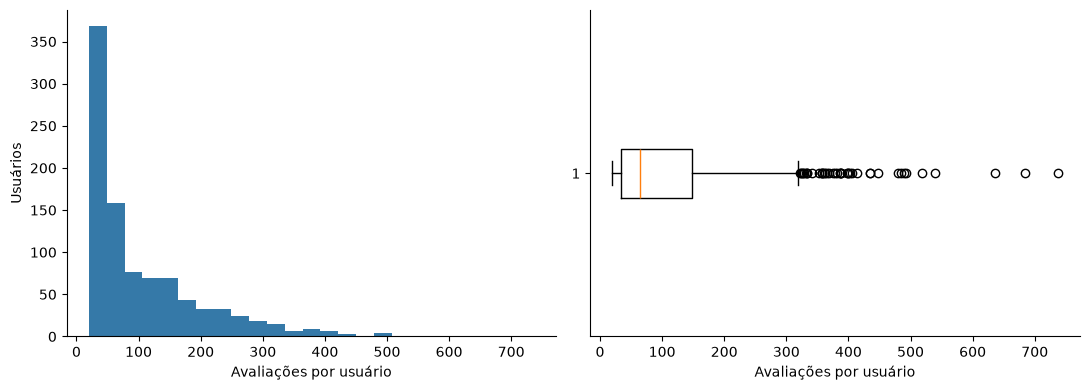

In [7]:
user_counts = ratings.groupby('user_id').size().rename('n_ratings')
display(save(user_counts.reset_index(),'ratings_per_user'))
display(user_counts.describe(percentiles=[.1,.25,.5,.75,.9]).to_frame('n_avaliacoes'))
fig,ax = plt.subplots(1,2,figsize=(11,4))
ax[0].hist(user_counts,bins=25,color='#3579a8'); ax[0].set(xlabel='Avaliações por usuário',ylabel='Usuários')
ax[1].boxplot(user_counts,vert=False); ax[1].set(xlabel='Avaliações por usuário')
plt.tight_layout(); plt.savefig(FIGURES / 'user_activity.png', dpi=150); plt.show()

In [8]:
display(Markdown(f"O histórico varia entre **{user_counts.min()} e {user_counts.max()}** notas, com mediana **{user_counts.median():.0f}**. O usuário mais ativo responde por **{user_counts.max()/len(ratings):.2%}** das notas. A desigualdade de atividade permite aprender melhor alguns perfis; para outros, vieses e vizinhos serão estimados com menos informação. Os 20 registros mínimos são consequência da seleção original: novos usuários sem histórico não estão representados nesse desenho."))

O histórico varia entre **20 e 737** notas, com mediana **65**. O usuário mais ativo responde por **0.74%** das notas. A desigualdade de atividade permite aprender melhor alguns perfis; para outros, vieses e vizinhos serão estimados com menos informação. Os 20 registros mínimos são consequência da seleção original: novos usuários sem histórico não estão representados nesse desenho.

,idade
count,943.000000
mean,34.051962
std,12.192740
min,7.000000
25%,25.000000
50%,31.000000
75%,43.000000
max,73.000000


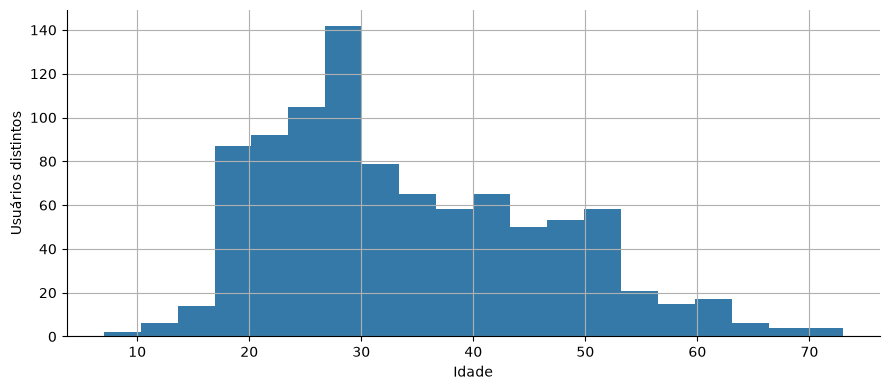

,gender,usuarios,avaliacoes,proporcao_usuarios,proporcao_avaliacoes
0,M,670,74260,0.710498,0.7426
1,F,273,25740,0.289502,0.2574


,occupation,usuarios,avaliacoes,proporcao_usuarios,proporcao_avaliacoes
0,student,196,21957,0.207847,0.21957
1,other,105,10663,0.111347,0.10663
2,educator,95,9442,0.100742,0.09442
3,administrator,79,7479,0.083775,0.07479
4,engineer,67,8175,0.071050,0.08175
5,programmer,66,7801,0.069989,0.07801
6,librarian,51,5273,0.054083,0.05273
7,writer,45,5536,0.047720,0.05536
8,executive,32,3403,0.033934,0.03403
9,scientist,31,2058,0.032874,0.02058


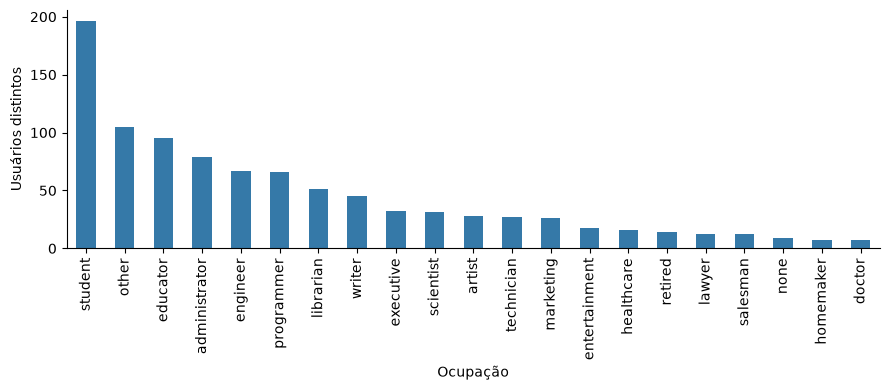

In [9]:
display(users.age.describe().to_frame('idade'))
users.age.hist(bins=20,color='#3579a8'); plt.xlabel('Idade'); plt.ylabel('Usuários distintos')
plt.tight_layout(); plt.savefig(FIGURES / 'user_age.png', dpi=150); plt.show()
for column in ['gender','occupation']:
    person = users[column].value_counts().rename('usuarios')
    weighted = ratings.merge(users[['user_id',column]],on='user_id',validate='many_to_one')[column].value_counts().rename('avaliacoes')
    table = pd.concat([person,weighted],axis=1)
    table['proporcao_usuarios'] = table.usuarios / len(users)
    table['proporcao_avaliacoes'] = table.avaliacoes / len(ratings)
    display(save(table.reset_index(names=column),'profile_'+column))
users.occupation.value_counts().plot.bar(color='#3579a8'); plt.ylabel('Usuários distintos'); plt.xlabel('Ocupação')
plt.tight_layout(); plt.savefig(FIGURES / 'occupations.png', dpi=150); plt.show()

In [10]:
male = users.gender.eq('M').mean()
student = users.occupation.eq('student').mean()
display(Markdown(f"A idade média é **{users.age.mean():.1f} anos**; a base registra **{male:.1%}** de usuários na categoria M e **{student:.1%}** de estudantes. As categorias de gênero são as registradas na coleta histórica e não devem ser interpretadas como uma descrição completa de identidades. As colunas de proporções distinguem pessoas de avaliações: diferenças entre elas decorrem da atividade. Este público voluntário e filtrado não representa toda a população."))

A idade média é **34.1 anos**; a base registra **71.0%** de usuários na categoria M e **20.8%** de estudantes. As categorias de gênero são as registradas na coleta histórica e não devem ser interpretadas como uma descrição completa de identidades. As colunas de proporções distinguem pessoas de avaliações: diferenças entre elas decorrem da atividade. Este público voluntário e filtrado não representa toda a população.

## 5. Filmes: popularidade e avaliação média
Popularidade significa quantidade de avaliações, não qualidade. Para comparar médias, aplicamos o mínimo de 50 notas definido no início. Mesmo assim, as médias não corrigem seleção de audiência nem diferenças de rigor entre usuários.

,item_id,n_ratings,mean_rating,title
49,50,583,4.358491,Star Wars (1977)
257,258,509,3.803536,Contact (1997)
99,100,508,4.155512,Fargo (1996)
180,181,507,4.007890,Return of the Jedi (1983)
293,294,485,3.156701,Liar Liar (1997)
285,286,481,3.656965,"English Patient, The (1996)"
287,288,478,3.441423,Scream (1996)
0,1,452,3.878319,Toy Story (1995)
299,300,431,3.631090,Air Force One (1997)
120,121,429,3.438228,Independence Day (ID4) (1996)


,item_id,n_ratings,mean_rating,title
407,408,112,4.491071,"Close Shave, A (1995)"
317,318,298,4.466443,Schindler's List (1993)
168,169,118,4.466102,"Wrong Trousers, The (1993)"
482,483,243,4.456790,Casablanca (1942)
113,114,67,4.447761,Wallace & Gromit: The Best of Aardman Animatio...
63,64,283,4.445230,"Shawshank Redemption, The (1994)"
602,603,209,4.387560,Rear Window (1954)
11,12,267,4.385768,"Usual Suspects, The (1995)"
49,50,583,4.358491,Star Wars (1977)
177,178,125,4.344000,12 Angry Men (1957)


,item_id,n_ratings,mean_rating,title
0,1,452,3.878319,Toy Story (1995)
1,2,131,3.206107,GoldenEye (1995)
2,3,90,3.033333,Four Rooms (1995)
3,4,209,3.550239,Get Shorty (1995)
4,5,86,3.302326,Copycat (1995)
...,...,...,...,...
1677,1678,1,1.000000,Mat' i syn (1997)
1678,1679,1,3.000000,B. Monkey (1998)
1679,1680,1,2.000000,Sliding Doors (1998)
1680,1681,1,3.000000,You So Crazy (1994)


,n_avaliacoes
count,1682.000000
mean,59.453032
std,80.383846
min,1.000000
10%,2.000000
25%,6.000000
50%,27.000000
75%,80.000000
90%,169.000000
max,583.000000


/tmp/ipykernel_7/381033449.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(movie_stats.n_ratings,vert=False); ax[1].set(xlabel='Avaliações por filme')


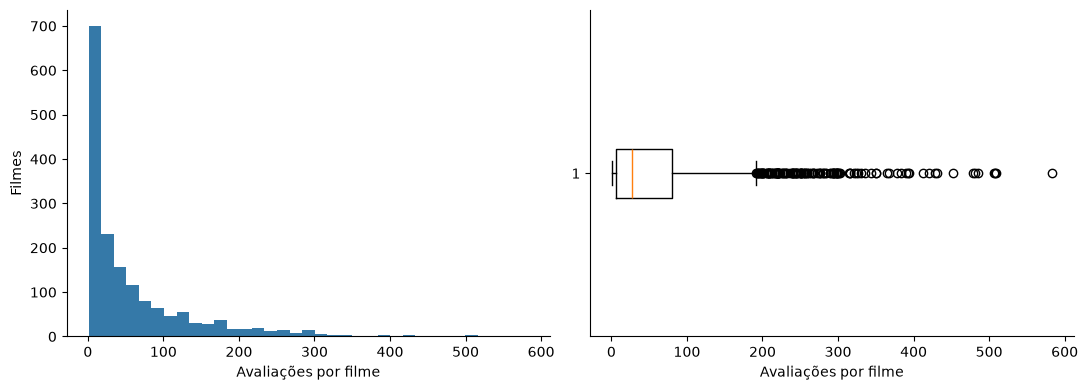

In [11]:
movie_stats = ratings.groupby('item_id').rating.agg(n_ratings='size',mean_rating='mean').reset_index().merge(items[['item_id','title']],on='item_id',validate='one_to_one')
popular = movie_stats.sort_values(['n_ratings','item_id'],ascending=[False,True]).head(10)
best = movie_stats[movie_stats.n_ratings>=50].sort_values(['mean_rating','n_ratings','item_id'],ascending=[False,False,True]).head(10)
display(save(popular,'popular_movies')); display(save(best,'best_rated_movies'))
display(save(movie_stats,'movie_statistics'))
display(movie_stats.n_ratings.describe(percentiles=[.1,.25,.5,.75,.9]).to_frame('n_avaliacoes'))
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].hist(movie_stats.n_ratings,bins=35,color='#3579a8'); ax[0].set(xlabel='Avaliações por filme',ylabel='Filmes')
ax[1].boxplot(movie_stats.n_ratings,vert=False); ax[1].set(xlabel='Avaliações por filme')
plt.tight_layout(); plt.savefig(FIGURES / 'item_activity.png', dpi=150); plt.show()

In [12]:
display(Markdown(f"**{popular.iloc[0].title}** é o filme mais avaliado, com **{popular.iloc[0].n_ratings}** notas. No ranking de médias elegíveis, **{best.iloc[0].title}** tem média **{best.iloc[0].mean_rating:.3f}**, apoiada em **{best.iloc[0].n_ratings}** notas. São critérios distintos. Há **{movie_stats.n_ratings.eq(1).sum()}** filmes com apenas uma avaliação; esses filmes seriam especialmente instáveis em um ranking irrestrito por média."))

**Star Wars (1977)** é o filme mais avaliado, com **583** notas. No ranking de médias elegíveis, **Close Shave, A (1995)** tem média **4.491**, apoiada em **112** notas. São critérios distintos. Há **141** filmes com apenas uma avaliação; esses filmes seriam especialmente instáveis em um ranking irrestrito por média.

,genero,filmes
0,Drama,725
1,Comedy,505
2,Action,251
3,Thriller,251
4,Romance,247
5,Adventure,135
6,Children's,122
7,Crime,109
8,Sci-Fi,101
9,Horror,92


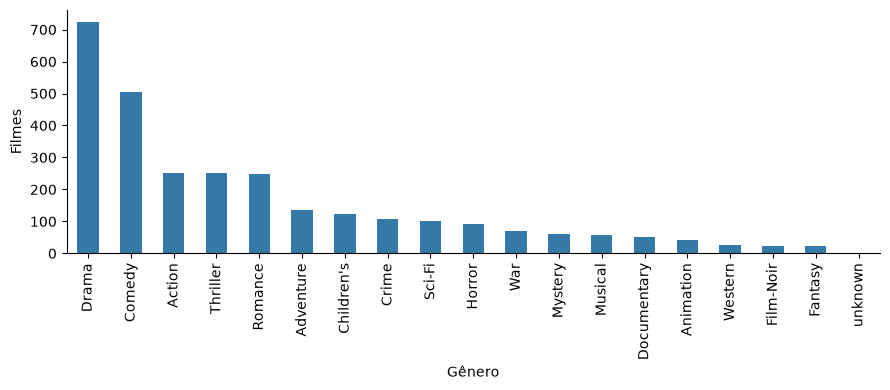

,year,filmes
0,1922.0,1
1,1926.0,1
2,1930.0,1
3,1931.0,1
4,1932.0,1
...,...,...
66,1994.0,214
67,1995.0,219
68,1996.0,355
69,1997.0,286


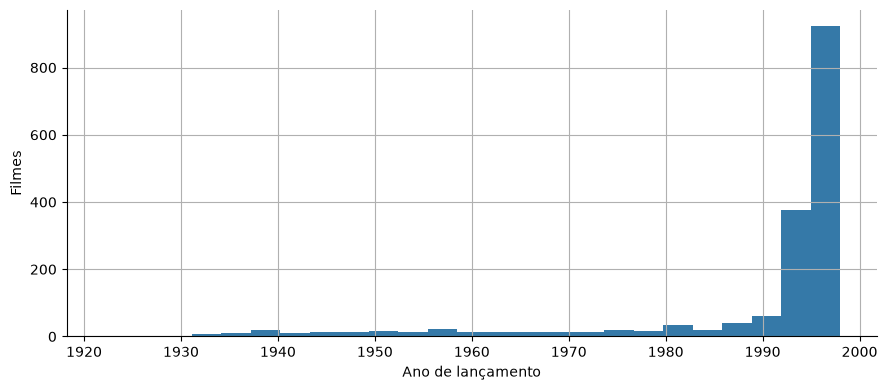

In [13]:
genre_counts=items[GENRES].sum().sort_values(ascending=False).rename('filmes').rename_axis('genero').reset_index()
display(save(genre_counts,'genre_counts'))
genre_counts.set_index('genero').filmes.plot.bar(color='#3579a8'); plt.ylabel('Filmes'); plt.xlabel('Gênero')
plt.tight_layout(); plt.savefig(FIGURES / 'genres.png', dpi=150); plt.show()
years=items.year.value_counts().sort_index().rename('filmes').reset_index()
display(save(years,'release_years'))
items.year.dropna().hist(bins=25,color='#3579a8'); plt.xlabel('Ano de lançamento'); plt.ylabel('Filmes')
plt.tight_layout(); plt.savefig(FIGURES / 'release_years.png', dpi=150); plt.show()

In [14]:
display(Markdown(f"O gênero mais frequente é **{genre_counts.iloc[0].genero}**, presente em **{genre_counts.iloc[0].filmes}** filmes. Um filme pode ter vários gêneros; a soma das categorias não é o tamanho do catálogo. O ano mediano é **{items.year.median():.0f}**; datas ausentes permanecem fora apenas do gráfico de anos, sem excluir avaliações ou filmes da modelagem."))

O gênero mais frequente é **Drama**, presente em **725** filmes. Um filme pode ter vários gêneros; a soma das categorias não é o tamanho do catálogo. O ano mediano é **1995**; datas ausentes permanecem fora apenas do gráfico de anos, sem excluir avaliações ou filmes da modelagem.

## 6. Esparsidade e implicações para os modelos
A densidade divide células observadas pelo total de pares possíveis. Não imputamos o restante. O cálculo usa a base inteira somente como descrição; os treinos serão ainda mais esparsos.

In [15]:
possible = len(users)*len(items)
density = len(ratings)/possible
sparsity = pd.DataFrame([{'usuarios':len(users),'filmes':len(items),'pares_possiveis':possible,'observadas':len(ratings),'densidade':density,'ausentes':1-density}])
display(save(sparsity,'sparsity'))
folds(ratings)
print(manual_checks())

,usuarios,filmes,pares_possiveis,observadas,densidade,ausentes
0,943,1682,1586126,100000,0.063047,0.936953


RMSE manual = √2,5; Precisão@10 manual = 2/10; cold start conferido.


In [16]:
display(Markdown(f"A matriz tem **943 × 1.682 = {possible:,}** células. Sua densidade é **{density:.2%}** e a proporção de ausências é **{1-density:.2%}**, abaixo do exemplo superior a 99% citado na aula. KNN precisa de avaliações em comum; SVD compartilha informação em fatores e usa regularização. Filmes raros têm pouco suporte. A amostra oferece histórico para todos os usuários, mas não resolve cold start de pessoas ou filmes novos."))

A matriz tem **943 × 1.682 = 1,586,126** células. Sua densidade é **6.30%** e a proporção de ausências é **93.70%**, abaixo do exemplo superior a 99% citado na aula. KNN precisa de avaliações em comum; SVD compartilha informação em fatores e usa regularização. Filmes raros têm pouco suporte. A amostra oferece histórico para todos os usuários, mas não resolve cold start de pessoas ou filmes novos.

## Síntese que orienta a modelagem
A base é íntegra nas chaves e na escala das notas, mas apresenta desigualdade de atividade, concentração de popularidade e muitas células desconhecidas. A avaliação precisa preservar essas ausências e impedir uso do teste no aprendizado. Por isso, os próximos notebooks compartilham folds, candidatos e critérios de relevância, além de dois referenciais distintos: média global para estrelas e popularidade para listas.

Fonte: Harper e Konstan (2015), *The MovieLens Datasets: History and Context*, DOI [10.1145/2827872](https://doi.org/10.1145/2827872). Dados históricos e seleção de voluntários limitam generalizações para plataformas atuais.